In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

1. Import Data

In [2]:
listings_data = pd.read_csv('../Data/listings.csv')
reviews_data = pd.read_csv('../Data/reviews.csv')
neighborhoods_data = pd.read_csv('../Data/neighbourhoods.csv')

In [5]:
original_listings = listings_data.copy()

In [27]:
def basic_exploration(df):
    print(f'Data shape: {df.shape}')
    print(f'Data info: ')
    display(df.info())
    print(f'Describe numerical data: ')
    display(df.describe())
    print(f'Describe categorical data: ')
    display(df.describe(include='O'))
    

In [28]:
basic_exploration(listings_data)

Data shape: (25449, 18)
Data info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25449 entries, 0 to 25448
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              25449 non-null  int64  
 1   name                            25449 non-null  object 
 2   host_id                         25449 non-null  int64  
 3   host_name                       25447 non-null  object 
 4   neighbourhood_group             25449 non-null  object 
 5   neighbourhood                   25449 non-null  object 
 6   latitude                        25449 non-null  float64
 7   longitude                       25449 non-null  float64
 8   room_type                       25449 non-null  object 
 9   price                           21870 non-null  float64
 10  minimum_nights                  25449 non-null  int64  
 11  number_of_reviews               25449 non-null  int64  
 

None

Describe numerical data: 


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,2.544900e+04,2.544900e+04,25449.000000,25449.000000,21870.000000,25449.000000,25449.000000,22255.000000,25449.000000,25449.000000,25449.000000
mean,6.052322e+17,2.287182e+08,38.762926,-9.207847,248.116049,4.719989,69.289206,1.566873,25.998075,217.148061,13.638257
std,5.914290e+17,2.214487e+08,0.114548,0.112146,1812.958718,16.810821,110.598085,1.551474,64.004266,129.336846,18.592469
min,6.499000e+03,1.445500e+04,38.675790,-9.486970,9.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,2.635673e+07,2.868791e+07,38.711030,-9.287910,75.000000,1.000000,3.000000,0.390000,1.000000,90.000000,0.000000
50%,6.598273e+17,1.462857e+08,38.719520,-9.147947,110.000000,2.000000,21.000000,1.090000,5.000000,263.000000,5.000000
75%,1.182779e+18,4.389003e+08,38.746920,-9.135128,167.000000,3.000000,86.000000,2.320000,16.000000,332.000000,21.000000
max,1.513766e+18,7.196566e+08,39.304030,-8.862100,86733.000000,1000.000000,1787.000000,29.720000,391.000000,365.000000,329.000000


Describe categorical data: 


,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review,license
count,25449,25447,25449,25449,25449,22255,24290
unique,24514,3804,16,129,4,1661,13613
top,Excelente Quarto Central,Pedro,Lisboa,Santa Maria Maior,Entire home/apt,2025-09-07,Exempt
freq,47,647,17428,3482,18824,760,4882


2. Data Exploration

In [ ]:
def select_numeric(df):
    return df.select_dtypes(include=np.number)

listings_data_numeric = select_numeric(listings_data)

In [29]:
def check_nulls(df):
    return df.isna().sum()

check_nulls(listings_data)

id                                   0
name                                 0
host_id                              0
host_name                            2
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                             3579
minimum_nights                       0
number_of_reviews                    0
last_review                       3194
reviews_per_month                 3194
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           1159
dtype: int64

Weak correlations across key features (especially price) indicate that model-based imputation would introduce noise rather than signal.

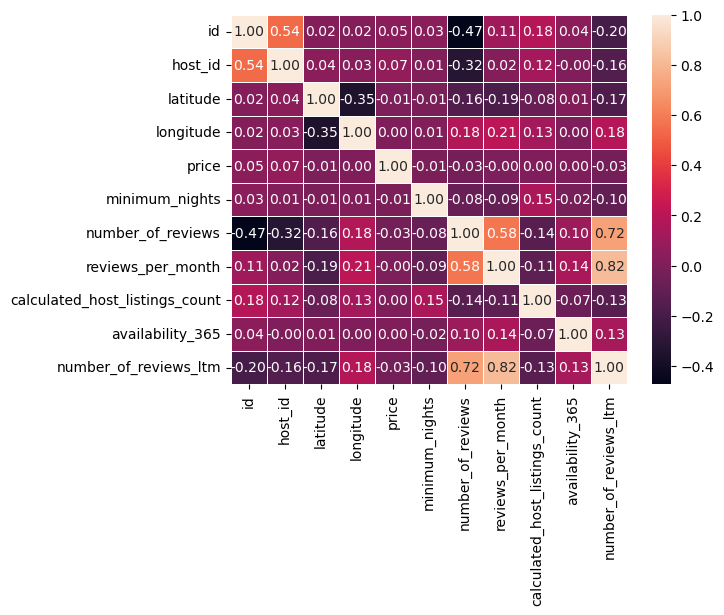

In [30]:
def check_correlation(df):
    corr_matrix = df.corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidth=0.5)
    
check_correlation(listings_data_numeric)

### Missing Value Strategy

- reviews_per_month:
  Set to 0 only where number_of_reviews == 0

- last_review:
  Left as NaT when no reviews

- price:
  Missing values preserved due to weak correlation and lack of reliable imputation strategy.
  Missing indicator added.

- host_name / license:
  Missing values flagged; no reliable reconstruction available.

**host_name** is not critical for downstream analytical tasks and cannot be reliably reconstructed from **host_id**. Therefore, missing values are preserved and flagged.

In [17]:
def inspect_missing_host_names(df):
    missing_hosts = df[df["host_name"].isna()]

    print(f"Rows with missing host_name: {len(missing_hosts)}")
    display(missing_hosts)

    return missing_hosts

In [18]:
missing_hosts = inspect_missing_host_names(listings_data)

Rows with missing host_name: 2


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
17971,1119436558815581889,Challet Judith,568673320,NaN,Cascais,Carcavelos e Parede,38.691489,-9.354692,Entire home/apt,266.0,4,26,2025-08-31,1.55,1,17,20,154997/AL
23231,1421801346889033452,Stylish Avenida Apartment,695699847,NaN,Lisboa,Santo Antnio,38.716290,-9.145730,Entire home/apt,162.0,2,3,2025-07-15,0.97,1,4,3,83208/AL


In [13]:
def inspect_host_ids(df, host_ids):
    return df[df["host_id"].isin(host_ids)]

In [14]:
inspect_host_ids(listings_data, [568673320, 695699847])

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
17971,1119436558815581889,Challet Judith,568673320,NaN,Cascais,Carcavelos e Parede,38.691489,-9.354692,Entire home/apt,266.0,4,26,2025-08-31,1.55,1,17,20,154997/AL
23231,1421801346889033452,Stylish Avenida Apartment,695699847,NaN,Lisboa,Santo Antnio,38.716290,-9.145730,Entire home/apt,162.0,2,3,2025-07-15,0.97,1,4,3,83208/AL
